# Load factor control


<a class="reference download internal" download="" href="https://github.com/simpsoba/benchmarks/blob/master/benchmarks/frame-1010/frame-1010.ipynb">
  <code class="xref download docutils literal notranslate">
    <span class="pre">Download</span>
  </code>
</a>


Hockling problem, as desribed by Perez and Filippou (2024).

## Modeling

In [ ]:
from xara.benchmarks import Prism
import xara
from shps.rotor import exp
import numpy as np

In [2]:

ne = 20
E  = 71_240
G  = 27_190
I  = 0.0833
A  = 10.0
J  = 2.16
L  = 240.0

def create_model(element):

    prism = Prism(
        length = L,
        element = element,
        material = dict(
            E   = E,
            G   = G,
        ),
        shape   = dict(
            A   = A,
            J   = J,
            Iy  = I,
            Iz  = I,
            Ay  = A,
            Az  = A),
        boundary = ((1,1,1, 1,1,1),
                    (0,1,1, 0,1,1)),
        transform = "Corotational02",
        divisions = ne,
        rotation = exp([0,  0.0, 0.005])
    )

    return prism.create_model()

## Analysis

ForceFrame


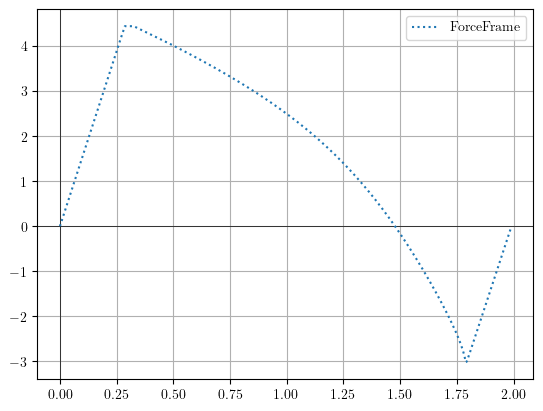

In [ ]:

import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.grid("on")
ax.axvline(0, color='k', lw=0.5)
ax.axhline(0, color='k', lw=0.5)

Markers = iter((":", "."))

for element in ["ForceFrame"]:
    print(element)
    model = create_model(element)

    #
    # Analysis
    #
    scale = 5 #0.0
    steps = 65
    Tref  = 2*E*I/L

    f = [0, 0, 0] + list(map(float, [Tref, 0, 0]))

    model.pattern("Plain", 1, "Linear", load={
        ne+1: f
    })

    analysis = xara.StaticAnalysis(model, 
        test=("NormDispIncr", 1e-9, 52, 0),
        integrator=xara.LoadFactorControl("MinUnbalDispNorm", 1, 5,  1/steps/800, 1),
        system="BandGeneral"
    )

    u = []
    lam = []
    time = []

    for i in range(390):
        u.append(model.nodeDisp(ne+1, 4)/np.pi)
        time.append(model.getTime())
        lam.append(model.getLoadFactor(1))
        try:
            analysis.analyze()
        except:
            break


    ax.plot(u, lam,  next(Markers), label=element)

ax.legend()



## References

1. C. M. Perez and F. C. Filippou, "On nonlinear geometric transformations of finite elements," Numerical Meth Engineering, vol. 125, no. 17, Sep. 2024, doi: [10.1002/nme.7506](https://onlinelibrary.wiley.com/doi/10.1002/nme.7506).
